In [10]:
#!/usr/bin/env python3
"""
Mesh Visualization with Periodic Boundary Condition

Author: Moon Ying (yying7@jh.edu)
Python Version: 3.9.7

This script generates a 3D triangular mesh similar to `graph_limit_surface_single.ipynb`
but with periodic boundary conditions.
A central peak and its surrounding area are 
highlighted in light blue to distinguish real vertices from the rest of the mesh,
for visualization of periodic boundary condition used in the continuum membrane model
The mesh structure is built using PyVista.

Key Features:
- Generates a structured triangular mesh.
- Introduces height variations to create a peak effect.
- Highlights a specific 8x6 region in light blue.

"""
import numpy as np
import matplotlib.pyplot as plt
import pyvista as pv
from mpl_toolkits.mplot3d import Axes3D


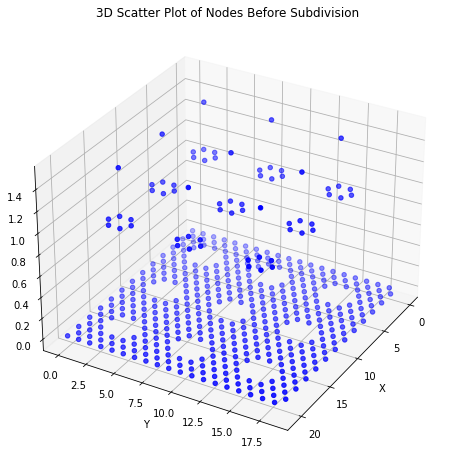

In [2]:
# Define the array to hold the points (now with 3 coordinates: x, y, z)
X = np.zeros((25, 19, 3))

# Generate points for equilateral triangles with a slight bump in the middle
for i in range(0, 25):
    for j in range(0, 19):
        X[i][j][0] = i * np.sqrt(3) / 2.0
        X[i][j][1] = j * 1.0 + (i % 2) * 0.5
        # Create a bump in the middle
        ipbc = i % 8 # considering pbc, what is index within local box?
        jpbc = j % 6 # ^
        if (ipbc,jpbc) == (4,3):
            X[i][j][2] = 1.5
        elif 3 <= ipbc <= 5 and 2 <= jpbc <= 3 or (ipbc,jpbc) == (4,4):
            X[i][j][2] = 1.0
        else:
            X[i][j][2] = 0.0

# Plot the 3D scatter plot of the points before subdivision
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, :, 0], X[:, :, 1], X[:, :, 2], color='blue')

ax.set_title("3D Scatter Plot of Nodes Before Subdivision")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.view_init(elev=30, azim=30)
plt.show()

In [3]:

# Flatten the array for pyvista mesh creation
points = X.reshape(-1, 3)

# Create pyvista PolyData object
mesh = pv.PolyData(points)

# Define the connectivity of the mesh (triangles)
faces = []
for i in range(24):
    for j in range(18):
        p1 = i * 19 + j
        p2 = (i + 1) * 19 + j
        p3 = p1 + 1
        p4 = p2 + 1
        if i % 2 == 0 :
            faces.append([3, p1, p2, p3])  # Triangle 1
            faces.append([3, p3, p2, p4])  # Triangle 2
        else:
            faces.append([3, p1, p3, p4])  # Triangle 1
            faces.append([3, p1, p4, p2])  # Triangle 2

# Convert list to numpy array with shape (n_faces, 4)
faces = np.array(faces).flatten()
print(faces)

[  3   0  19 ... 454 474 473]


/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


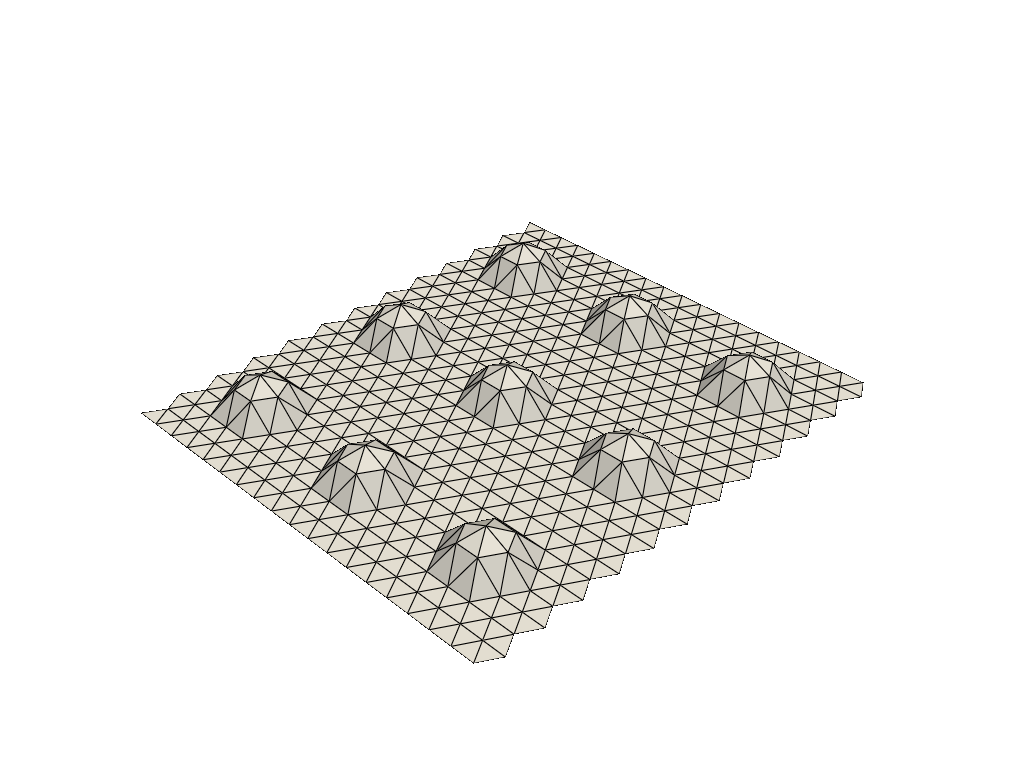

In [4]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Plot the subdivided mesh with edge connectivity
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
plotter.add_mesh(tri_mesh, show_edges=True, color='white')

plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


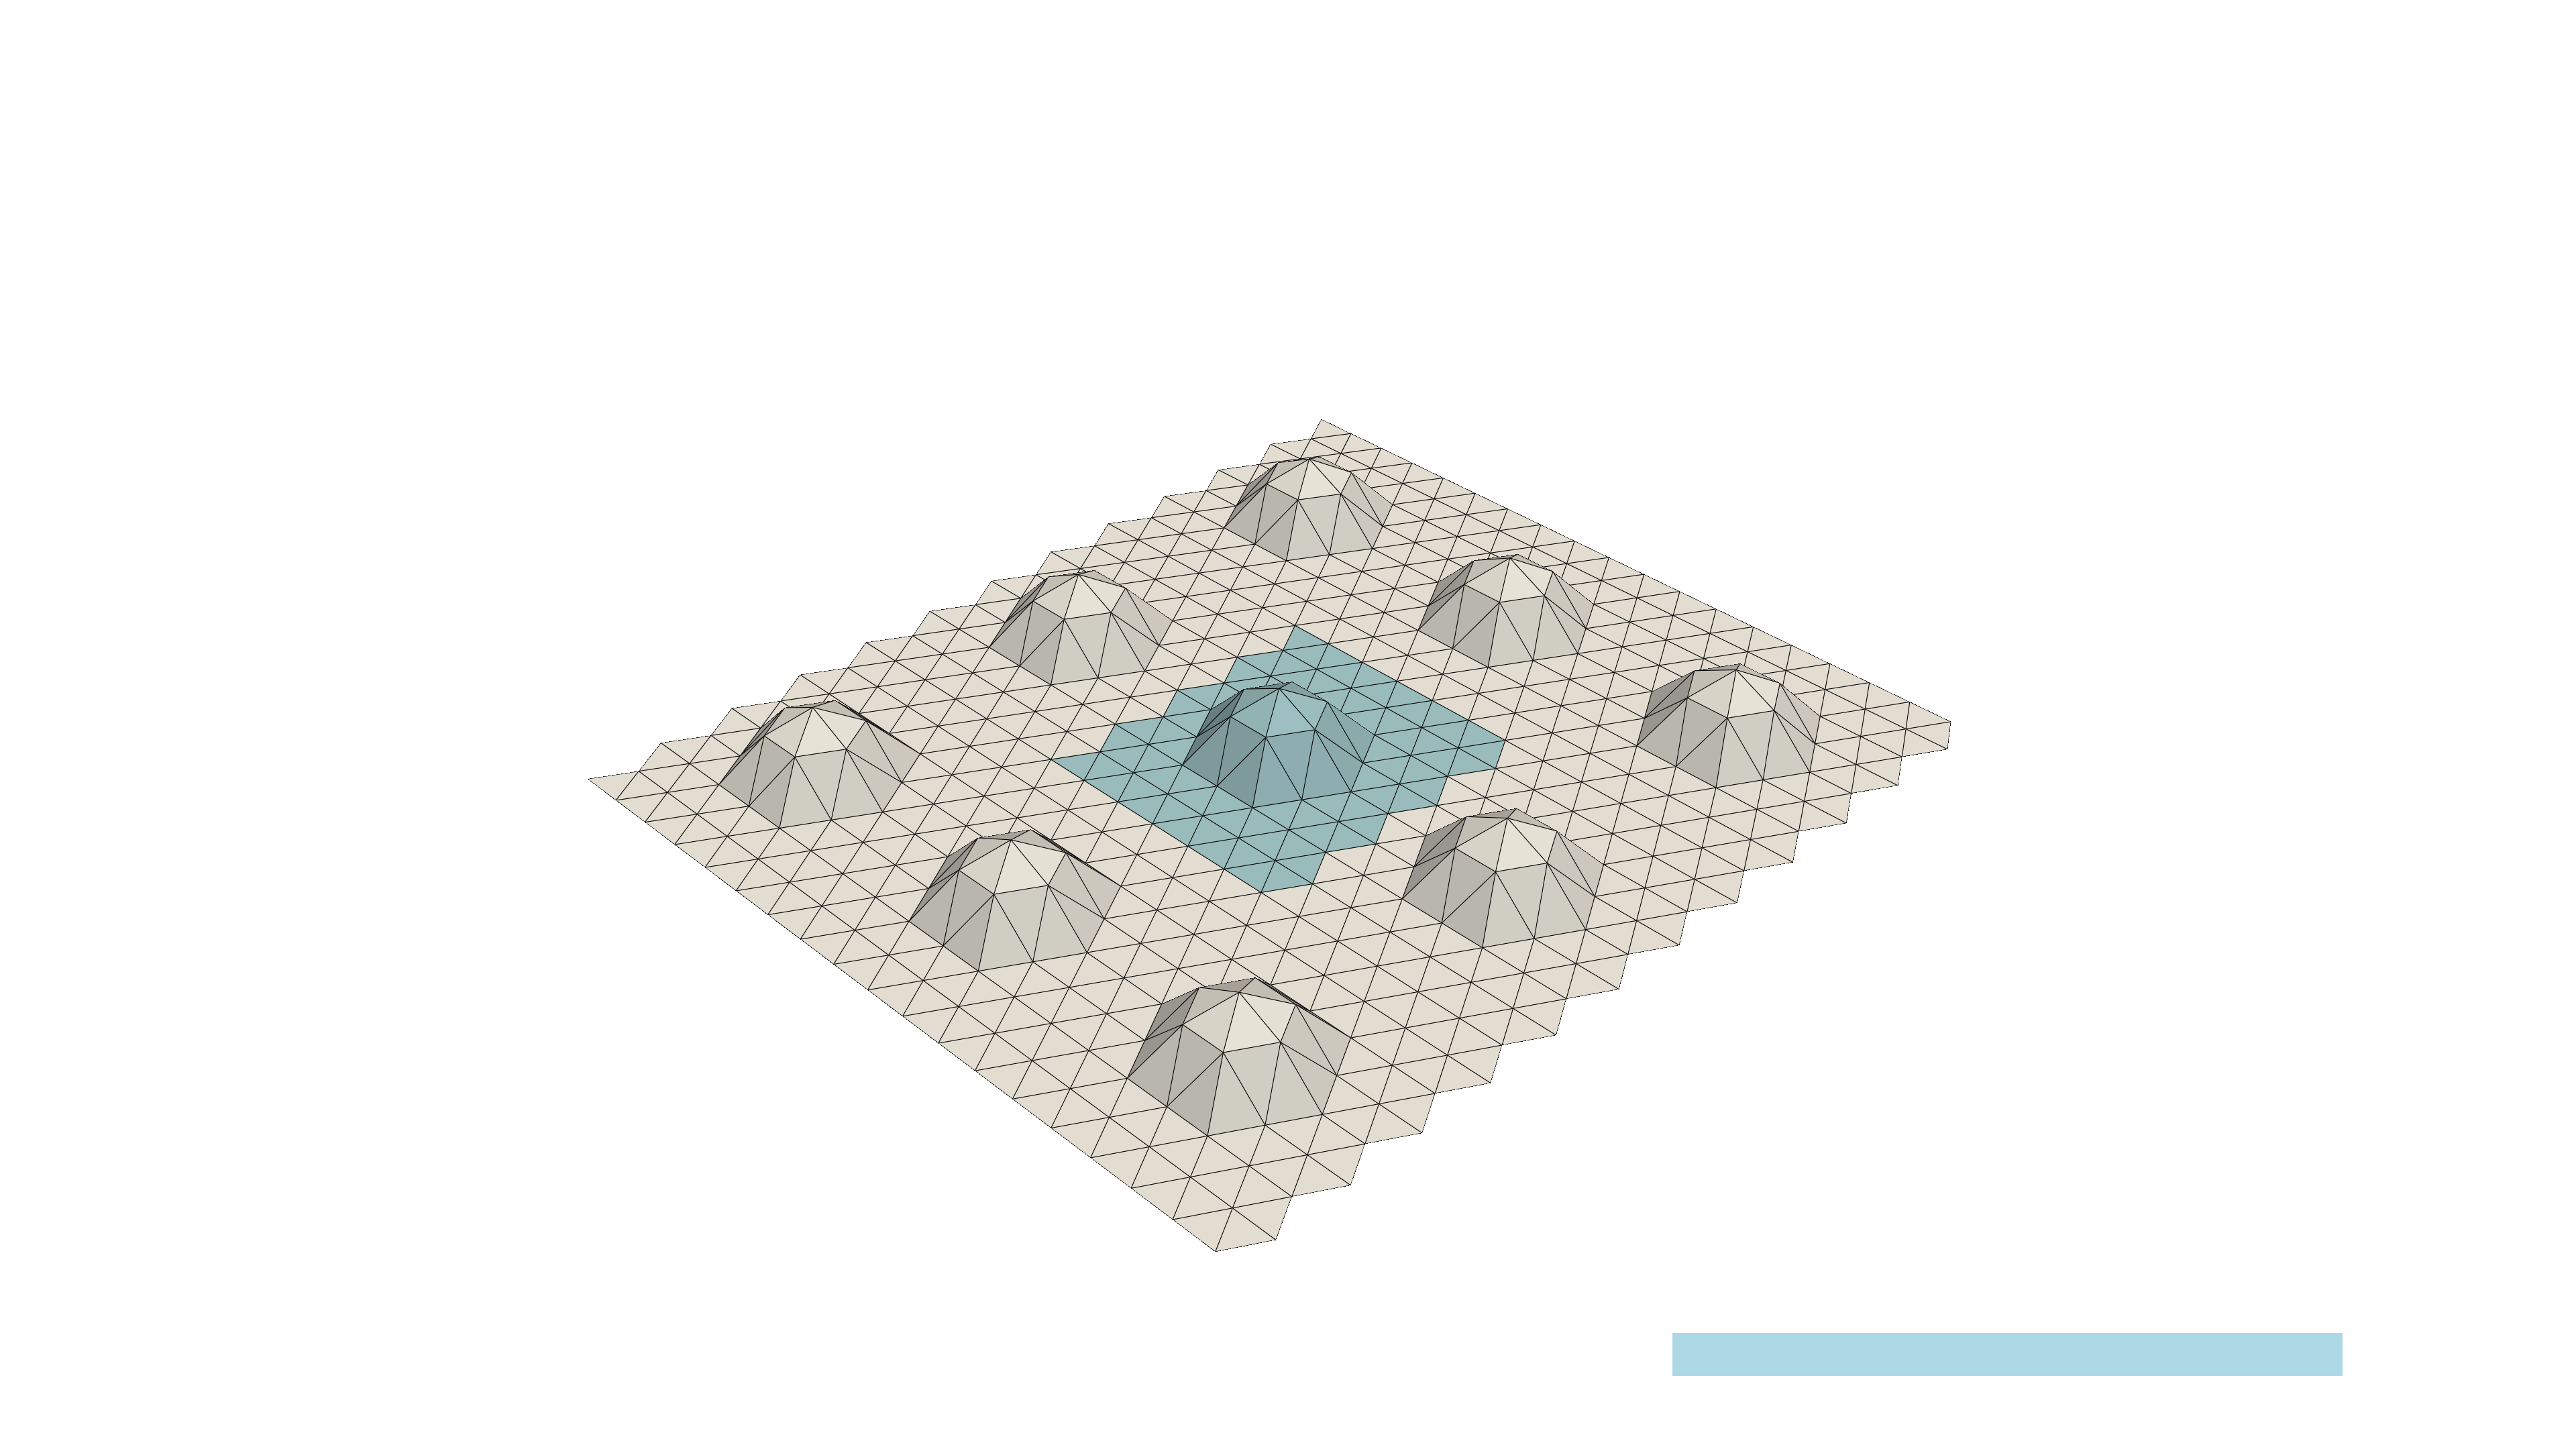

In [5]:
# Flatten the array for pyvista mesh creation
points = X.reshape(-1, 3)

# Create pyvista PolyData object
mesh = pv.PolyData(points)

# Define the connectivity of the mesh (triangles)
faces = []
colors = []
num_cols = 19

highlight_indices = set()
for i in range(9, 16):  # Highlight box for middle peak
    for j in range(7, 12):
        highlight_indices.add(i * num_cols + j)

for i in range(24):
    for j in range(18):
        p1 = i * 19 + j
        p2 = (i + 1) * 19 + j
        p3 = p1 + 1
        p4 = p2 + 1
        if i % 2 == 0:
            faces.append([3, p1, p2, p3])  # Triangle 1
            faces.append([3, p3, p2, p4])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p3 in highlight_indices or p2 in highlight_indices or p4 in highlight_indices or p1 in highlight_indices else 0)
        else:
            faces.append([3, p1, p3, p4])  # Triangle 1
            faces.append([3, p1, p4, p2])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)

# Convert list to numpy array
faces = np.array(faces).flatten()
colors = np.array(colors)

# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Define color mapping
cmap = {0: 'white', 1: 'lightblue'}
plotter = pv.Plotter()
plotter.background_color = 'white'
plotter.add_mesh(tri_mesh, show_edges=True, scalars=colors, cmap=['white', 'lightblue'], clim=[0, 1])
# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_PBC_middlehighlight.png')
plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


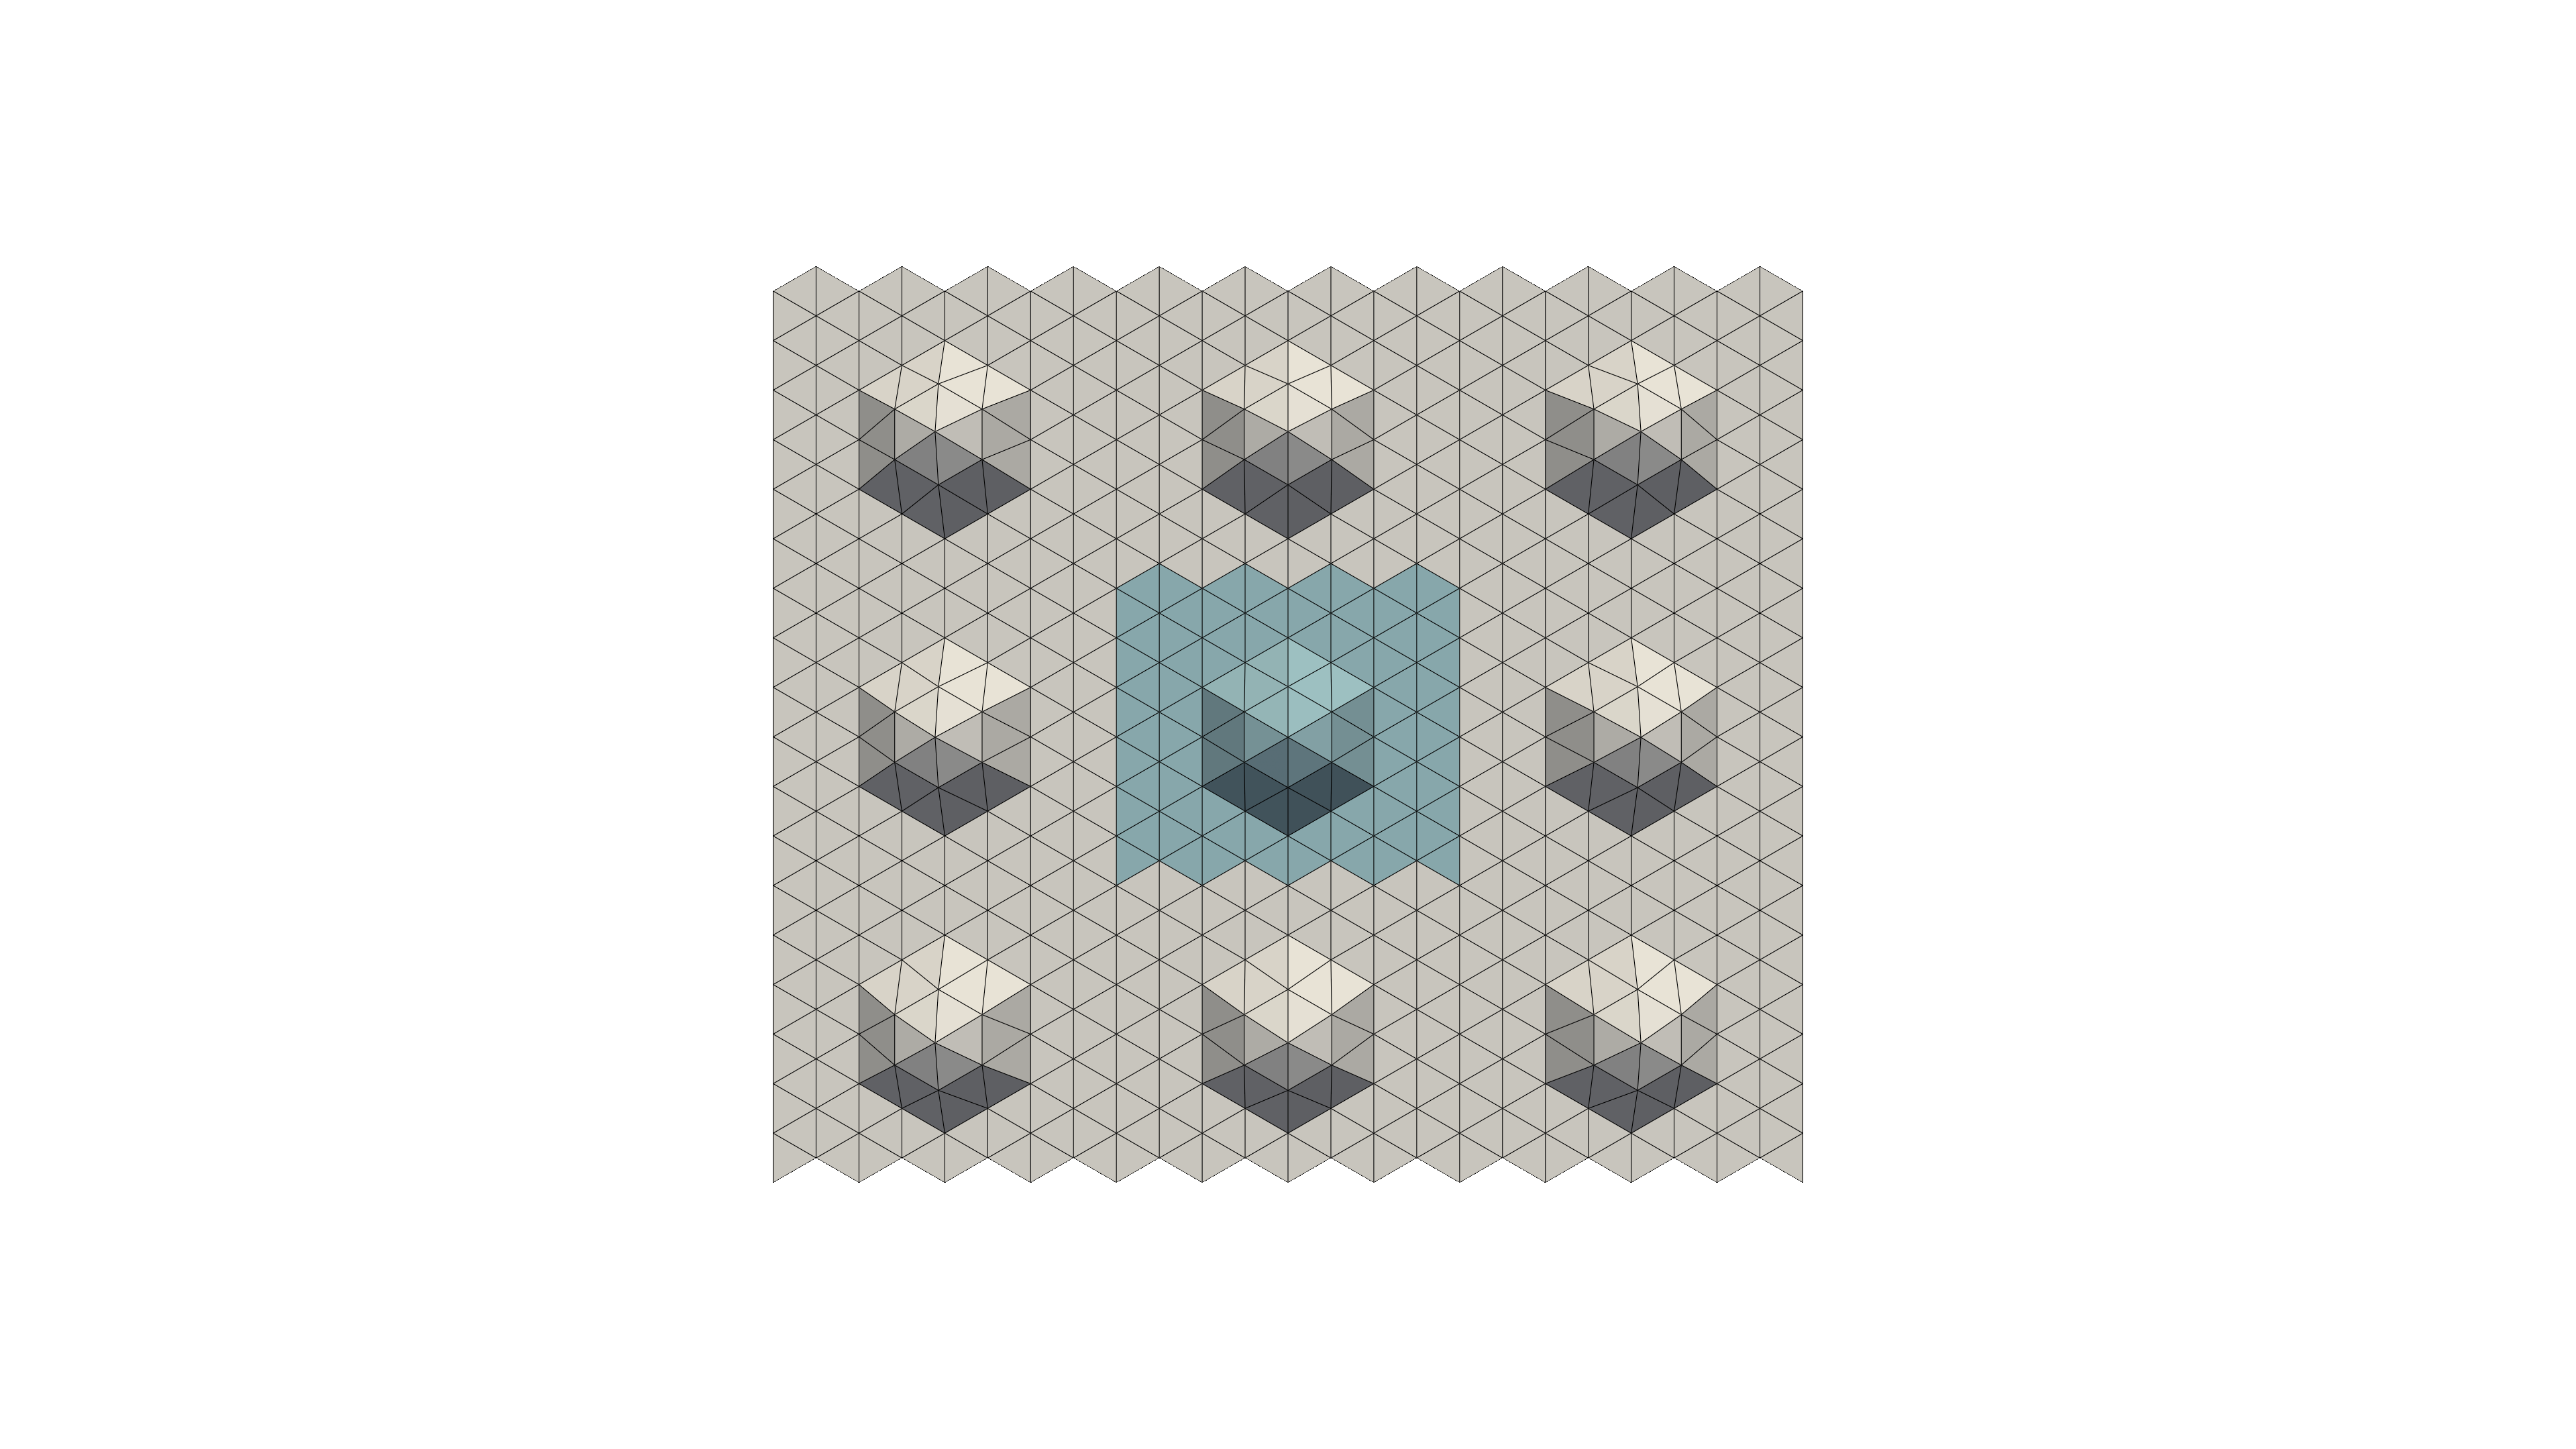

In [6]:
# Flatten the array for pyvista mesh creation
points = X.reshape(-1, 3)

# Create pyvista PolyData object
mesh = pv.PolyData(points)

# Define the connectivity of the mesh (triangles)
faces = []
colors = []
num_cols = 19

highlight_indices = set()
for i in range(9, 16):  # Highlight box for middle peak
    for j in range(7, 12):
        highlight_indices.add(i * num_cols + j)

for i in range(24):
    for j in range(18):
        p1 = i * 19 + j
        p2 = (i + 1) * 19 + j
        p3 = p1 + 1
        p4 = p2 + 1
        if i % 2 == 0:
            faces.append([3, p1, p2, p3])  # Triangle 1
            faces.append([3, p3, p2, p4])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p3 in highlight_indices or p2 in highlight_indices or p4 in highlight_indices or p1 in highlight_indices else 0)
        else:
            faces.append([3, p1, p3, p4])  # Triangle 1
            faces.append([3, p1, p4, p2])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)

# Convert list to numpy array
faces = np.array(faces).flatten()
colors = np.array(colors)

# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Define color mapping
cmap = {0: 'white', 1: 'lightblue'}
plotter = pv.Plotter()
plotter.background_color = 'white'
plotter.add_mesh(tri_mesh, show_edges=True, scalars=colors, cmap=['white', 'lightblue'],show_scalar_bar=False)
plotter.view_xy()
# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_PBC_topdown.png')
plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


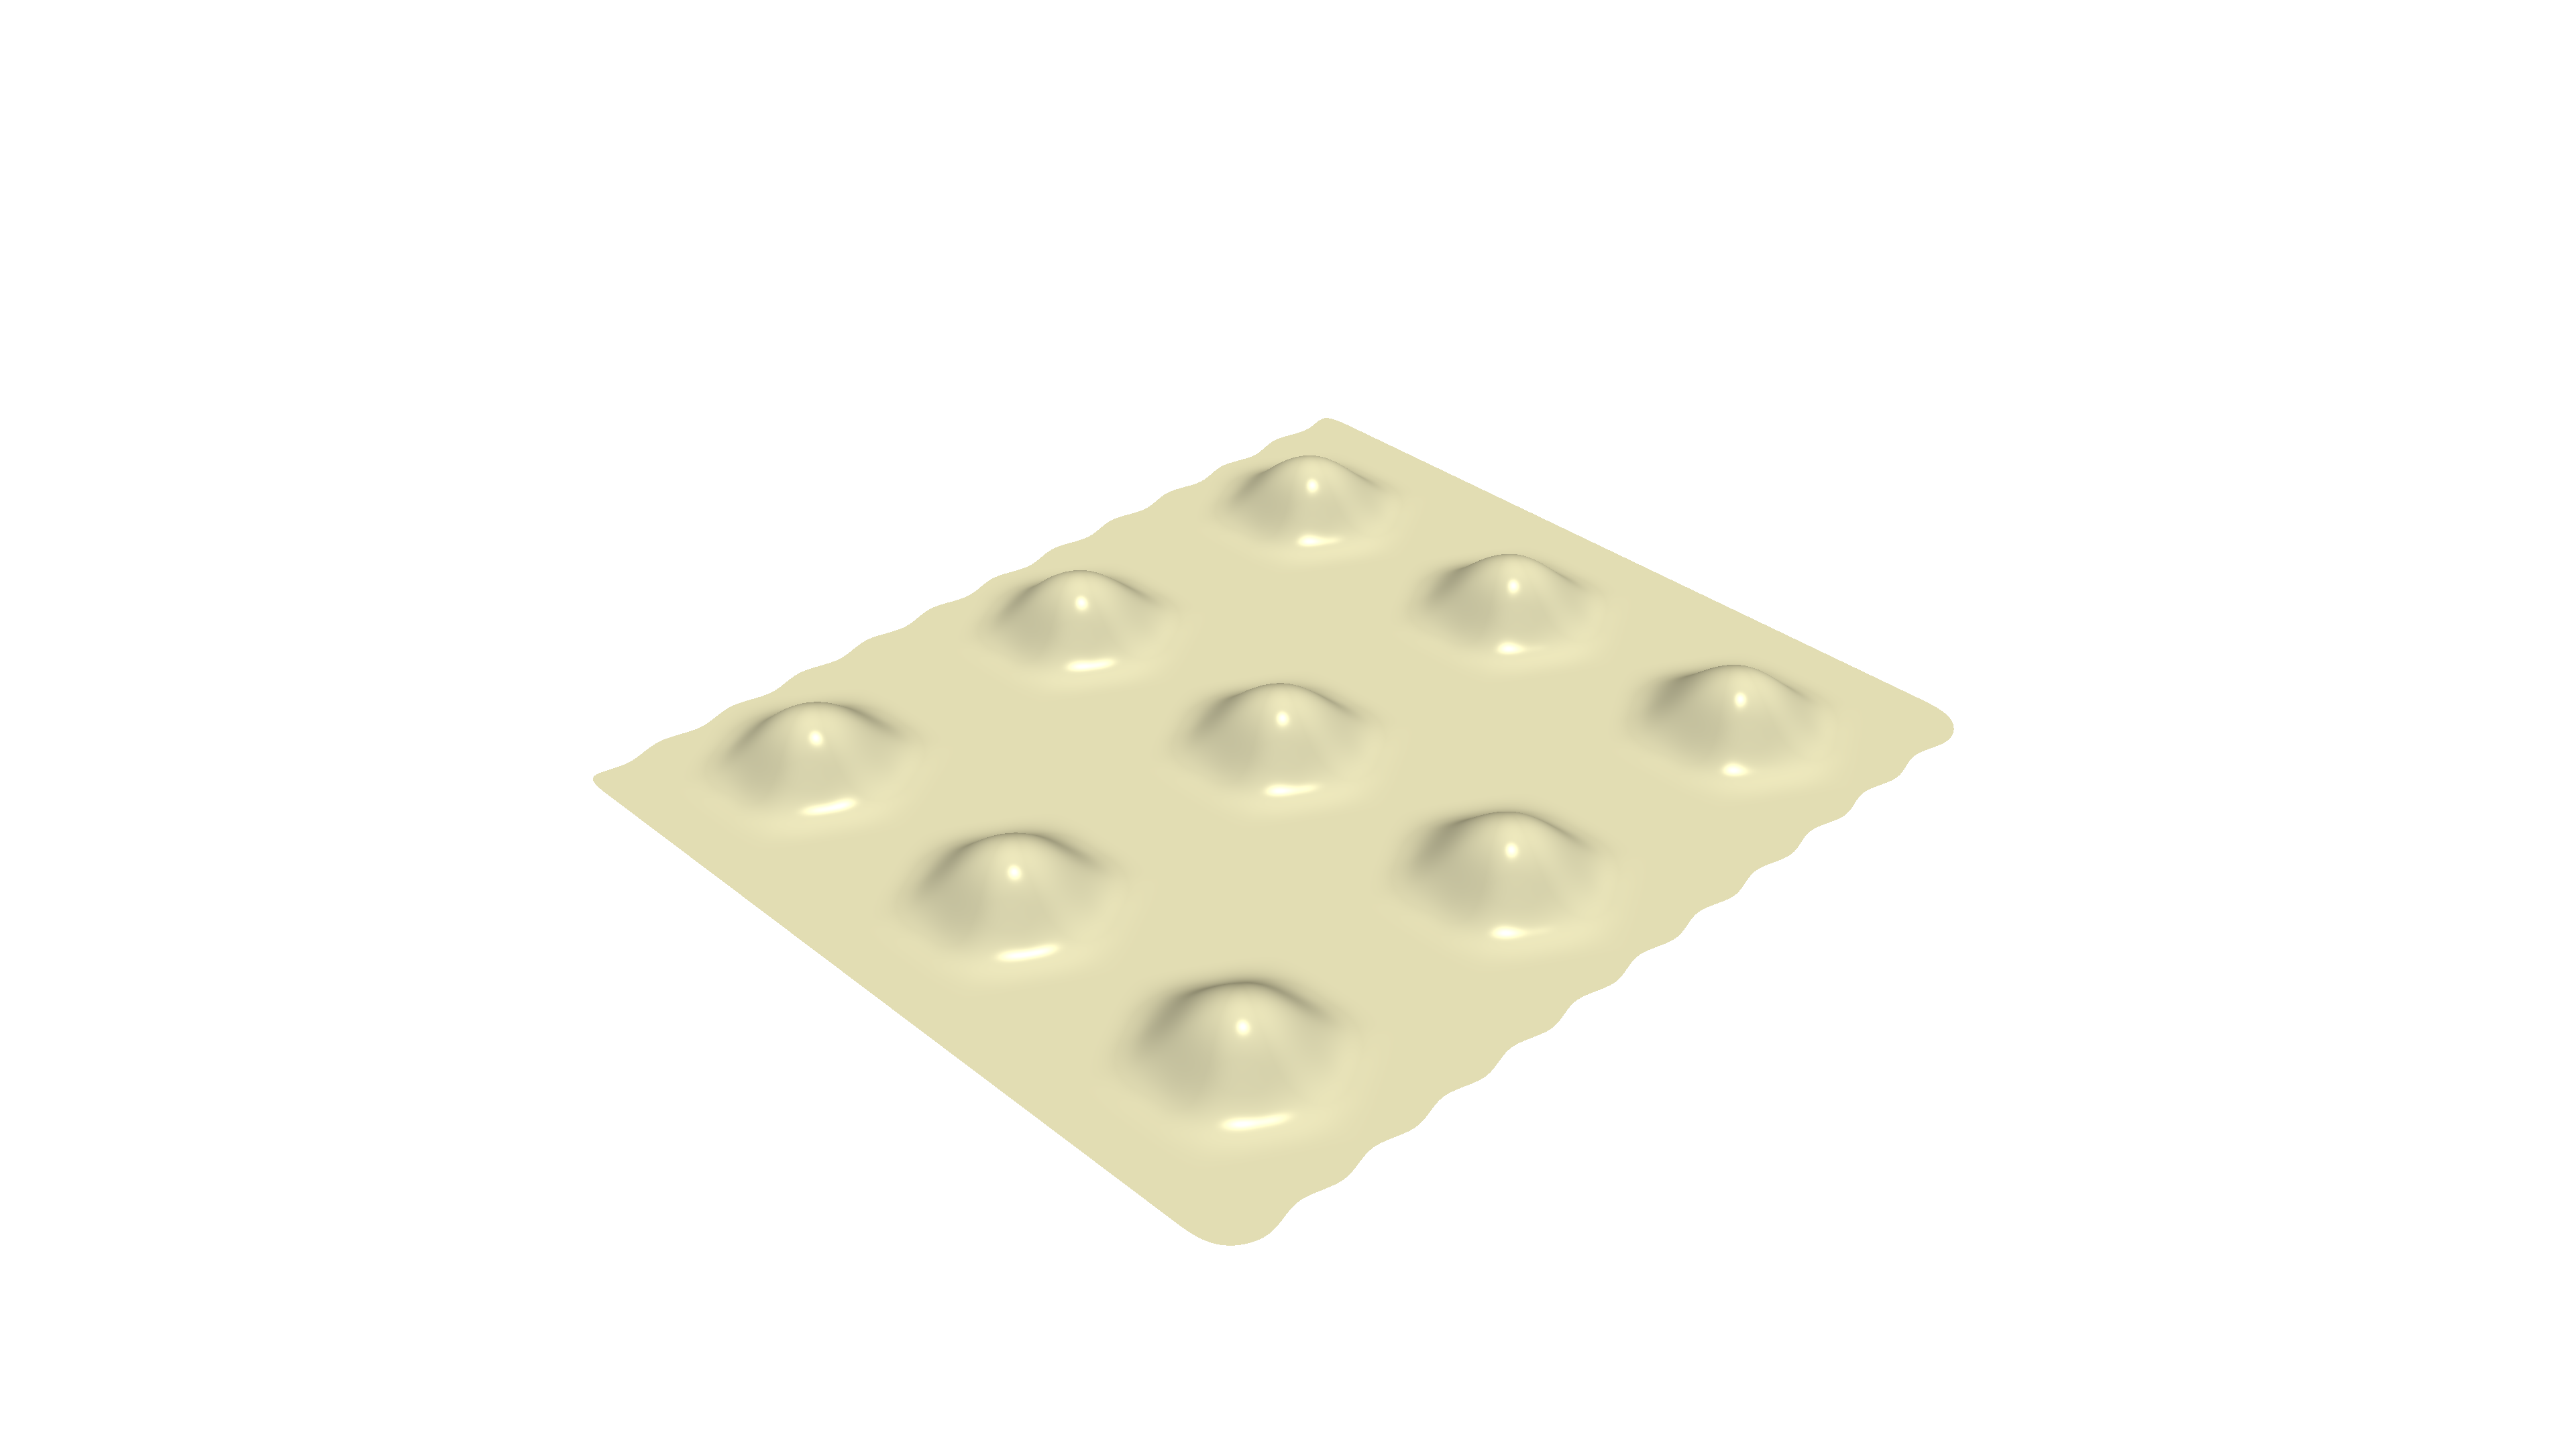

In [7]:
# Flatten the array for pyvista mesh creation
points = X.reshape(-1, 3)

# Create pyvista PolyData object
mesh = pv.PolyData(points)

# Define the connectivity of the mesh (triangles)
faces = []
colors = []
num_cols = 19

highlight_indices = set()
for i in range(9, 16):  # Highlight box for middle peak
    for j in range(7, 12):
        highlight_indices.add(i * num_cols + j)

for i in range(24):
    for j in range(18):
        p1 = i * 19 + j
        p2 = (i + 1) * 19 + j
        p3 = p1 + 1
        p4 = p2 + 1
        if i % 2 == 0:
            faces.append([3, p1, p2, p3])  # Triangle 1
            faces.append([3, p3, p2, p4])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p3 in highlight_indices or p2 in highlight_indices or p4 in highlight_indices or p1 in highlight_indices else 0)
        else:
            faces.append([3, p1, p3, p4])  # Triangle 1
            faces.append([3, p1, p4, p2])  # Triangle 2
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)
            colors.append(1 if p1 in highlight_indices or p2 in highlight_indices or p3 in highlight_indices or p4  in highlight_indices else 0)

# Convert list to numpy array
faces = np.array(faces).flatten()
colors = np.array(colors)

# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Define color mapping
cmap = {0: 'white', 1: 'lightblue'}
plotter = pv.Plotter()
plotter.background_color = 'white'

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(4, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5)
# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_PBC_smooth.png')
plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


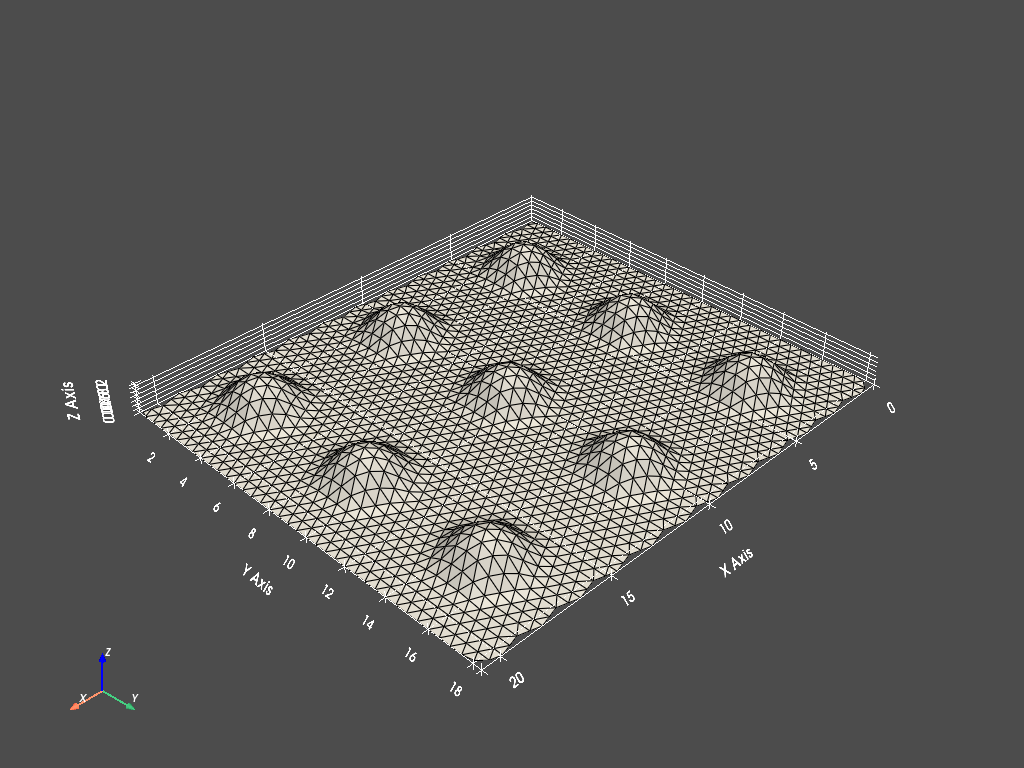

In [8]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(1, subfilter='loop')

# Plot the subdivided mesh with edge connectivity
plotter = pv.Plotter()
plotter.add_mesh(X_subdiv, show_edges=True, color='white')
plotter.show_grid()
plotter.show_axes()
plotter.view_isometric()
plotter.show()

/opt/anaconda3/lib/python3.9/site-packages/pyvista/jupyter/notebook.py:58: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  warnings.warn(


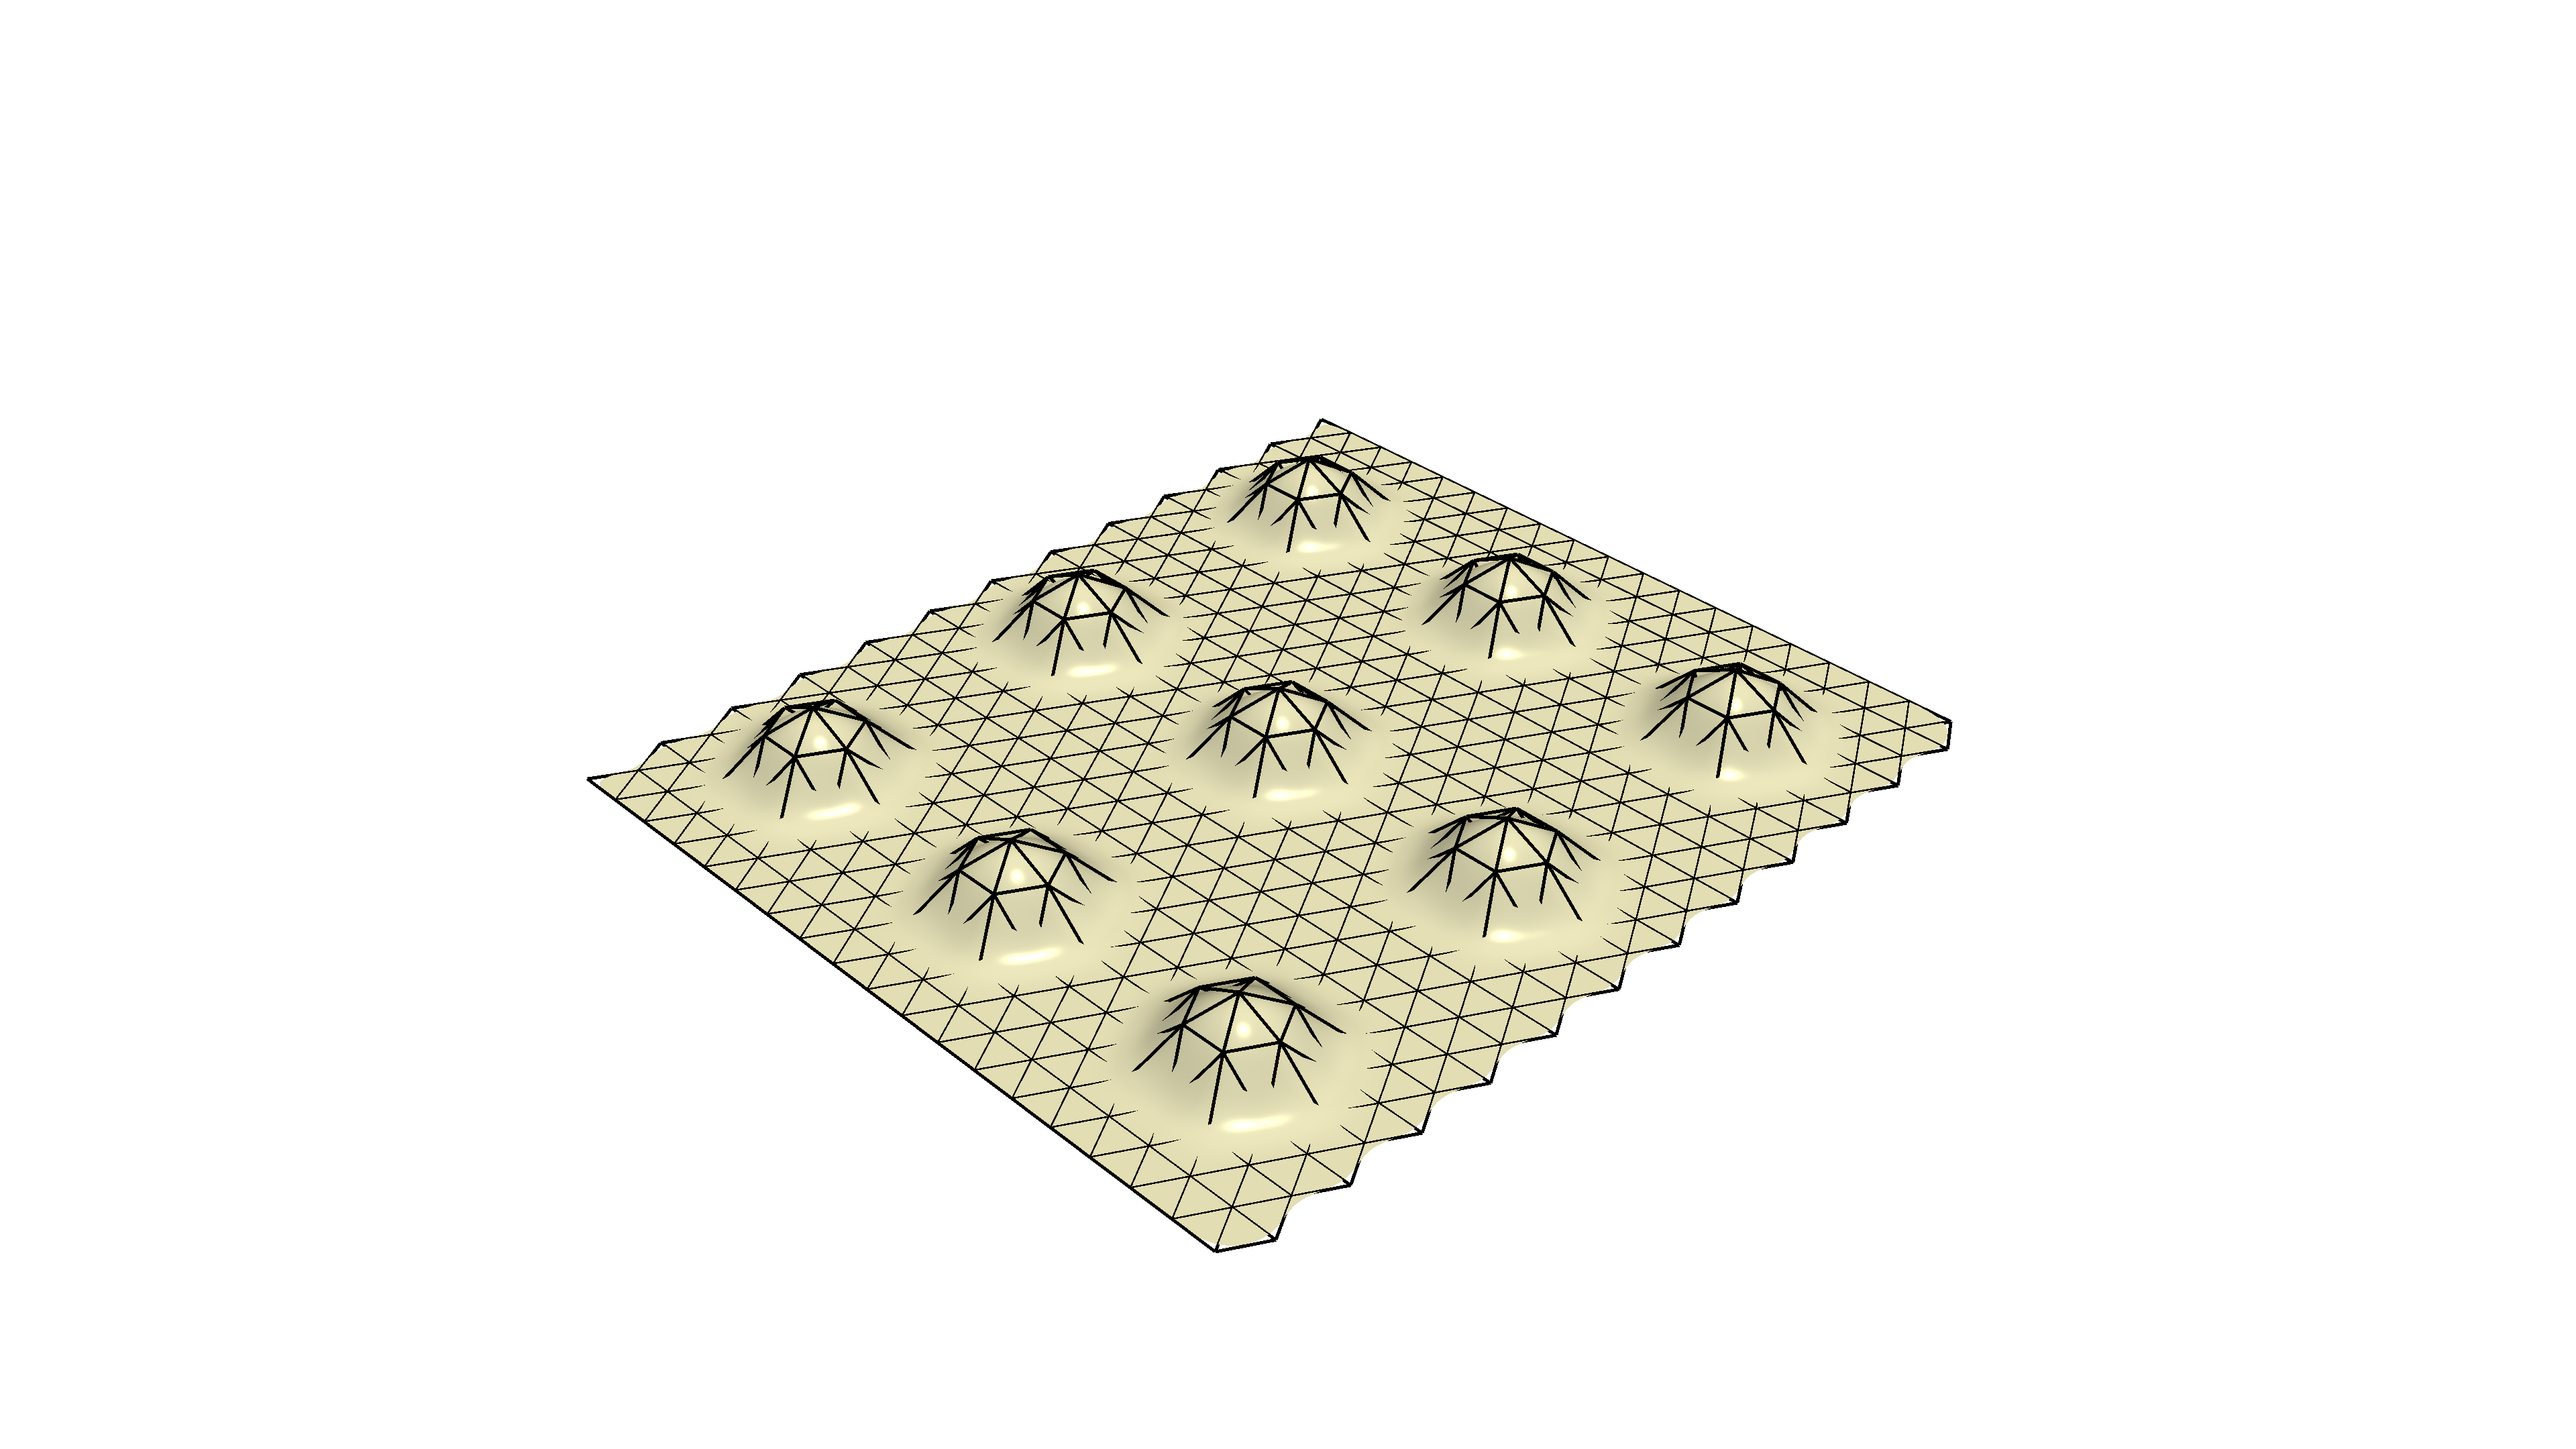

In [9]:
# Create the mesh
tri_mesh = pv.PolyData(mesh.points, faces)

# Apply Loop's subdivision
X_subdiv = tri_mesh.subdivide(5, subfilter='loop')

# Plot the original mesh edge connectivity
# Plot the subdivided mesh
plotter = pv.Plotter()
plotter.background_color = 'white'  # Set the background to white
plotter.add_mesh(tri_mesh, color='black', style='wireframe', line_width=5)
plotter.add_mesh(X_subdiv, show_edges=False, color='#FFFFDC',
                 smooth_shading=True, specular=0.5)

# Set a high window size for high resolution
plotter.window_size = [3840, 2160]  # Increase the size for higher resolution

# Render the plot and save as a high-resolution PNG
plotter.screenshot('graph_limit_surface_high_resolution_plot_PBC.png')

plotter.show()